# ChemSafe Assistant - Local Training

This notebook trains the GNN locally.

In [1]:
import os
import sys
import time
import json
import numpy as np
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Project root: c:\Projects\ChemSafe_Assistant
Device: cuda
GPU: NVIDIA GeForce GTX 1060


## 1. Loading Processed Data

In [2]:
from torch_geometric.loader import DataLoader

GRAPHS_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'graphs.pt')

if not os.path.exists(GRAPHS_PATH):
    print('! graphs.pt not found. Running preprocessing pipeline first...')
    from src.data.dataset import save_processed_pipeline
    csv_path = os.path.join(PROJECT_ROOT, 'data', 'raw', 'tox21.csv')
    save_processed_pipeline(csv_path, GRAPHS_PATH, desalt=True, seed=42)

data_splits = torch.load(GRAPHS_PATH)
train_graphs = data_splits['train']
val_graphs   = data_splits['val']
test_graphs  = data_splits['test']

print(f'Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}')

NUM_NODE_FEATURES = train_graphs[0].x.shape[1]
print(f'Node feature dim: {NUM_NODE_FEATURES}')


c:\Users\John\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\John\AppData\Local\Temp\ipykernel_37736\3477899641.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_g

Train: 5476 | Val: 1173 | Test: 1174
Node feature dim: 34


## 2. Initializing Model

In [3]:
from src.model.gnn import Tox21GNN

model = Tox21GNN(
    num_node_features=NUM_NODE_FEATURES,
    hidden_dim=128,
    num_tasks=12,
    dropout=0.3
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: Tox21GNN')
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')


Model: Tox21GNN
Total parameters: 138,508
Trainable parameters: 138,508


## 3. Starting Training

In [ ]:
from src.model.trainer import Trainer

# Set up the train_history directory and attempt folder
train_history_dir = os.path.join(PROJECT_ROOT, 'train_history')
os.makedirs(train_history_dir, exist_ok=True)
existing_attempts = [d for d in os.listdir(train_history_dir) if d.startswith('attempt_')]
attempt_nums = [int(d.split('_')[1]) for d in existing_attempts if d.split('_')[1].isdigit()]
next_attempt = max(attempt_nums) + 1 if attempt_nums else 1

attempt_dir = os.path.join(train_history_dir, f'attempt_{next_attempt}')
os.makedirs(attempt_dir, exist_ok=True)
print(f'Creating training history directory: {attempt_dir}')

SAVE_PATH = os.path.join(attempt_dir, 'gnn_tox21.pt')

trainer = Trainer(
    model=model,
    train_graphs=train_graphs,
    val_graphs=val_graphs,
    lr=1e-3,
    batch_size=1024,
    epochs=100,
    patience=15,
    save_path=SAVE_PATH,
    device=device
)

start_time = time.time()
history = trainer.train()
end_time = time.time()

training_time = end_time - start_time
history['training_time_seconds'] = training_time
hours, rem = divmod(training_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"\nTraining Duration: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

metrics_path = os.path.join(attempt_dir, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(history, f, indent=4)
print(f'Metrics data saved to {metrics_path}')


Creating training history directory: c:\Projects\ChemSafe_Assistant\train_history\attempt_1
Training on cuda for up to 100 epochs...
 Epoch |  Train Loss |  Val Loss |   Val AUC |    Val F1 |         LR
------------------------------------------------------------------------


c:\Users\John\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
c:\Users\John\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


     1 |      0.5438 |    0.6186 |    0.5246 |    0.0000 |   0.001000
         > Best model saved (val_loss=0.6186)


c:\Users\John\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


     2 |      0.3053 |    0.4121 |    0.5553 |    0.0000 |   0.001000
         > Best model saved (val_loss=0.4121)


...

    77 |      0.1874 |    0.1877 |    0.8321 |    0.2492 |   0.000125


c:\Users\John\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


    78 |      0.1847 |    0.1877 |    0.8315 |    0.2432 |   0.000125


c:\Users\John\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


    79 |      0.1841 |    0.1876 |    0.8317 |    0.2446 |   0.000125

! Early stopping triggered after 79 epochs (patience=15)

* Training complete. Best val_loss=0.1865

Training Duration: 0h 2m 54.15s
Metrics data saved to c:\Projects\ChemSafe_Assistant\train_history\attempt_1\metrics.json


## 4. Plotting Training Metrics

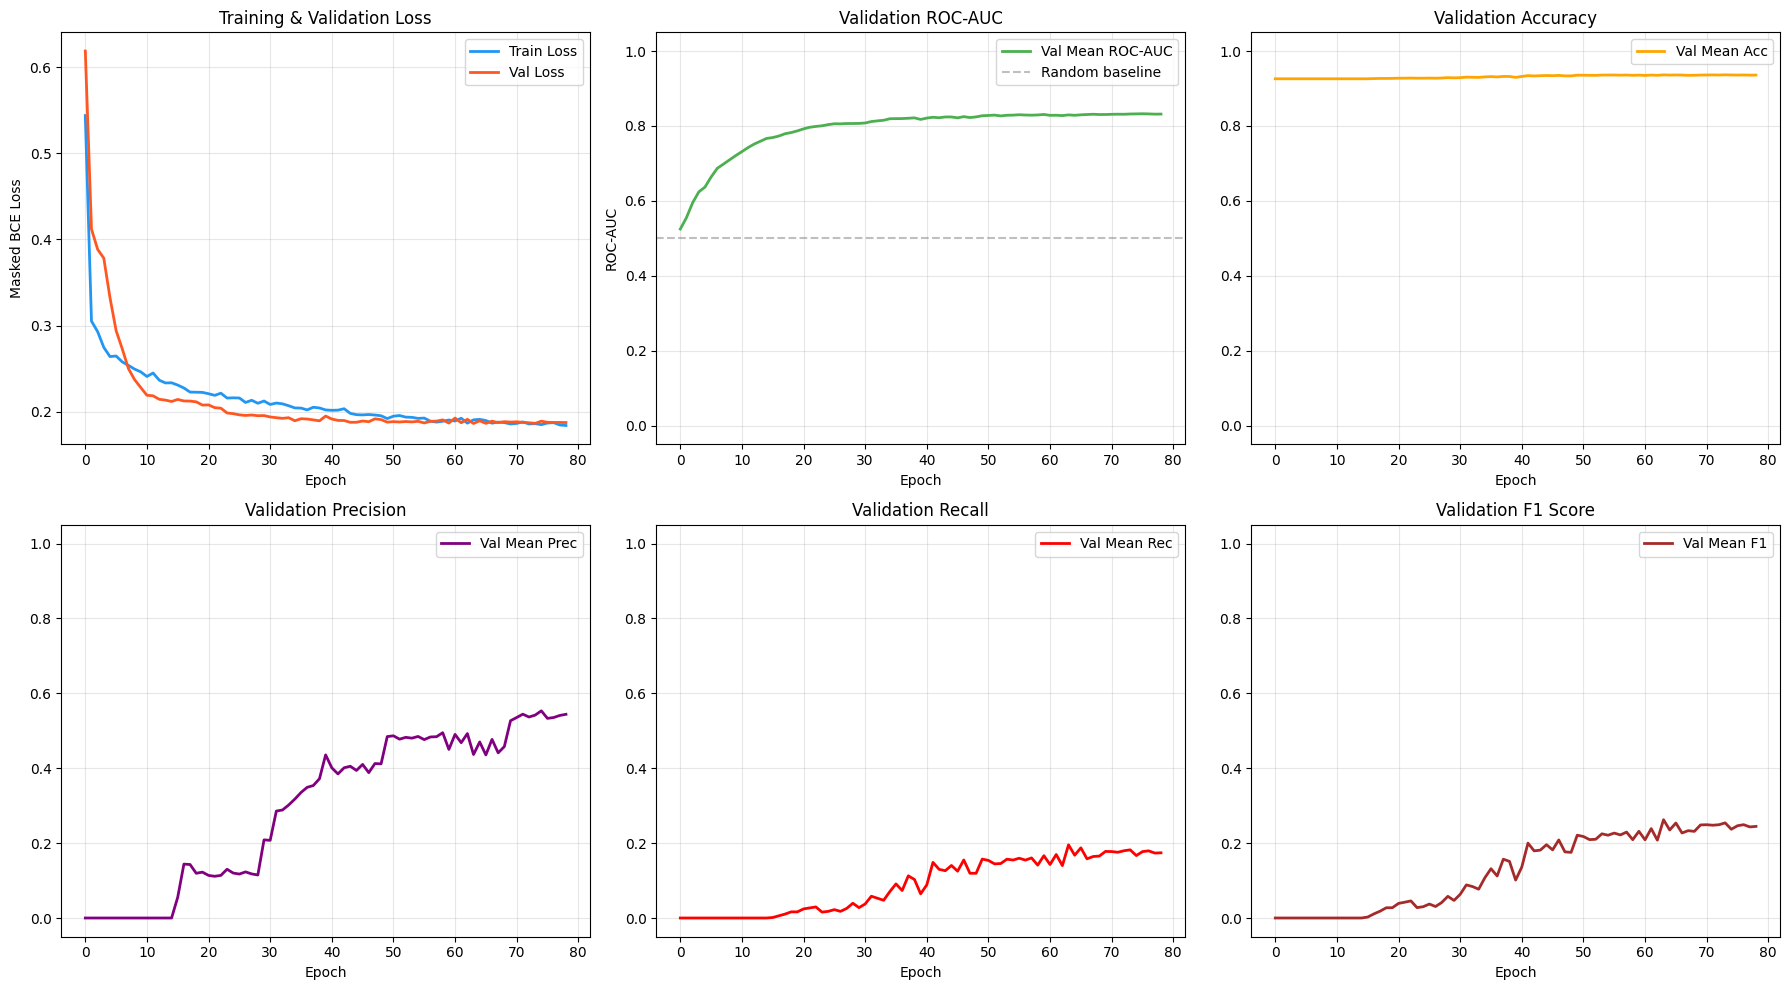

Training curves saved to c:\Projects\ChemSafe_Assistant\train_history\attempt_1\training_curves.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

axes[0].plot(history['train_losses'], label='Train Loss', color='#2196F3', linewidth=2)
axes[0].plot(history['val_losses'], label='Val Loss', color='#FF5722', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Masked BCE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_aucs'], label='Val Mean ROC-AUC', color='#4CAF50', linewidth=2)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Validation ROC-AUC')
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_accs'], label='Val Mean Acc', color='orange', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_title('Validation Accuracy')
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(history['val_precs'], label='Val Mean Prec', color='purple', linewidth=2)
axes[3].set_xlabel('Epoch')
axes[3].set_title('Validation Precision')
axes[3].set_ylim(-0.05, 1.05)
axes[3].legend()
axes[3].grid(True, alpha=0.3)

axes[4].plot(history['val_recs'], label='Val Mean Rec', color='red', linewidth=2)
axes[4].set_xlabel('Epoch')
axes[4].set_title('Validation Recall')
axes[4].set_ylim(-0.05, 1.05)
axes[4].legend()
axes[4].grid(True, alpha=0.3)

axes[5].plot(history['val_f1s'], label='Val Mean F1', color='brown', linewidth=2)
axes[5].set_xlabel('Epoch')
axes[5].set_title('Validation F1 Score')
axes[5].set_ylim(-0.05, 1.05)
axes[5].legend()
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(attempt_dir, 'training_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Training curves saved to {plot_path}')


## 5. Evaluating on Test Set

In [6]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from src.data.dataset import TOX21_LABELS

checkpoint = torch.load(SAVE_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

test_loader = DataLoader(test_graphs, batch_size=1024, shuffle=False)

all_preds = []
all_targets = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        logits = model(batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        labels = batch.y.view(-1, 12).cpu().numpy()
        all_preds.append(probs)
        all_targets.append(labels)

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

print('\nPer-Task Test Metrics:')
print('-' * 80)
print(f'{"Task":<20} | {"ROC-AUC":<10} | {"Accuracy":<10} | {"Precision":<10} | {"Recall":<10} | {"F1 Score":<10}')
print('-' * 80)

valid_aucs, valid_accs, valid_precs, valid_recs, valid_f1s = [], [], [], [], []
for i, name in enumerate(TOX21_LABELS):
    y_true = all_targets[:, i]
    y_score = all_preds[:, i]
    mask = ~np.isnan(y_true)
    y_true_v = y_true[mask]
    y_score_v = y_score[mask]
    if len(np.unique(y_true_v)) < 2:
        print(f'{name:<20} | {"N/A":<10} | {"N/A":<10} | {"N/A":<10} | {"N/A":<10} | {"N/A":<10}')
    else:
        y_pred_v = (y_score_v > 0.5).astype(int)
        auc = roc_auc_score(y_true_v, y_score_v)
        acc = accuracy_score(y_true_v, y_pred_v)
        prec = precision_score(y_true_v, y_pred_v, zero_division=0)
        rec = recall_score(y_true_v, y_pred_v, zero_division=0)
        f1 = f1_score(y_true_v, y_pred_v, zero_division=0)
        
        valid_aucs.append(auc)
        valid_accs.append(acc)
        valid_precs.append(prec)
        valid_recs.append(rec)
        valid_f1s.append(f1)
        print(f'{name:<20} | {auc:<10.4f} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f}')

mean_auc = np.mean(valid_aucs) if valid_aucs else 0.0
mean_acc = np.mean(valid_accs) if valid_accs else 0.0
mean_prec = np.mean(valid_precs) if valid_precs else 0.0
mean_rec = np.mean(valid_recs) if valid_recs else 0.0
mean_f1 = np.mean(valid_f1s) if valid_f1s else 0.0
print('-' * 80)
print(f'{"Mean":<20} | {mean_auc:<10.4f} | {mean_acc:<10.4f} | {mean_prec:<10.4f} | {mean_rec:<10.4f} | {mean_f1:<10.4f}')

# Save test metrics into the JSON file
test_metrics = {
    'mean_auc': mean_auc,
    'mean_acc': mean_acc,
    'mean_prec': mean_prec,
    'mean_rec': mean_rec,
    'mean_f1': mean_f1
}
history['test_metrics'] = test_metrics
with open(metrics_path, 'w') as f:
    json.dump(history, f, indent=4)

print(f'\nTraining and Evaluation complete.')
print(f'Best model checkpoint: {SAVE_PATH}')
print(f'Best val loss: {checkpoint["val_loss"]:.4f}')
print(f'Best val AUC:  {checkpoint["val_auc"]:.4f}')


C:\Users\John\AppData\Local\Temp\ipykernel_37736\3794021794.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(SAVE_PATH)



Per-Task Test Metrics:
--------------------------------------------------------------------------------
Task                 | ROC-AUC    | Accuracy   | Precision  | Recall     | F1 Score  
--------------------------------------------------------------------------------
NR-AR                | 0.8527     | 0.9743     | 0.9565     | 0.4490     | 0.6111    
NR-AR-LBD            | 0.9222     | 0.9820     | 0.8571     | 0.5455     | 0.6667    
NR-AhR               | 0.8827     | 0.9068     | 0.7843     | 0.3333     | 0.4678    
NR-Aromatase         | 0.8542     | 0.9453     | 0.0000     | 0.0000     | 0.0000    
NR-ER                | 0.7414     | 0.8957     | 0.6400     | 0.1538     | 0.2481    
NR-ER-LBD            | 0.8296     | 0.9576     | 1.0000     | 0.0833     | 0.1538    
NR-PPAR-gamma        | 0.8156     | 0.9721     | 0.0000     | 0.0000     | 0.0000    
SR-ARE               | 0.7939     | 0.8539     | 0.6897     | 0.1429     | 0.2367    
SR-ATAD5             | 0.8610     | 0.95